Day 1: trying to create a regression that can predict point shares for ONLY next season based on:

* previous 3 years point shares
* age
* seasons played
* games played prev. season
* games played cumulative
* draft round (if under a certain age)

In [2]:
!pip install pandas


[notice] A new release of pip is available: 23.2.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [3]:
!pip install matplotlib


[notice] A new release of pip is available: 23.2.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [4]:
%pip install scipy


[notice] A new release of pip is available: 23.2.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

In [6]:
import pandas as pd
df = pd.read_csv('player_stats.csv')
df.head()

,player_name,player_id,position,draft_year,draft_round,draft_pick,draft_team,season,age,team,league,games_played,cumulative_gp,seasons_played,point_shares,point_shares_prev1,point_shares_prev2,point_shares_prev3,delta_ps,next_season_ps
0,Owen Nolan,nolanow01,RW,1990,1,NaN,Quebec Nordiques,1990-91,18.0,QUE,NHL,59,59,1,-0.8,NaN,NaN,NaN,NaN,6.9
1,Owen Nolan,nolanow01,RW,1990,1,NaN,Quebec Nordiques,1991-92,19.0,QUE,NHL,75,134,2,6.9,-0.8,NaN,NaN,7.7,6.5
2,Owen Nolan,nolanow01,RW,1990,1,NaN,Quebec Nordiques,1992-93,20.0,QUE,NHL,73,207,3,6.5,6.9,-0.8,NaN,-0.4,0.4
3,Owen Nolan,nolanow01,RW,1990,1,NaN,Quebec Nordiques,1993-94,21.0,QUE,NHL,6,213,4,0.4,6.5,6.9,-0.8,-6.1,6.5
4,Owen Nolan,nolanow01,RW,1990,1,NaN,Quebec Nordiques,1994-95,22.0,QUE,NHL,46,259,5,6.5,0.4,6.5,6.9,6.1,5.0


Cool. Pandas is installed and the data is accesible. Lets play around with it a little bit

In [7]:
numeric_columns = df.select_dtypes(include=['number']).columns
print(df[numeric_columns].describe())

         draft_year   draft_round  draft_pick           age  games_played  \
count  20968.000000  20968.000000         0.0  20967.000000  20968.000000   
mean    2004.218428      3.072253         NaN     25.819574     48.996089   
std        8.773036      2.357470         NaN      4.253646     28.393924   
min     1990.000000      1.000000         NaN     18.000000      1.000000   
25%     1996.000000      1.000000         NaN     23.000000     22.000000   
50%     2004.000000      2.000000         NaN     25.000000     56.000000   
75%     2011.000000      4.000000         NaN     29.000000     75.250000   
max     2025.000000     12.000000         NaN     45.000000     85.000000   

       cumulative_gp  seasons_played  point_shares  point_shares_prev1  \
count   20968.000000    20968.000000  20968.000000        17710.000000   
mean      301.599914        5.536961      2.426674            2.693535   
std       293.173720        4.052167      2.827360            2.872755   
min       

Looks like the data is running fine. One thing that I want to do is clean up the data for delta_ps since some values need to be slightly rounded after scraping.

In [8]:
df['delta_ps'] = df['delta_ps'].round(1)

Lets poke around w/ the data set: 
* how does player progression (delta_ps) change as players age?
* point share totals by draft round?
* variance of point shares by age?
* change in point shares by age for each draft round?

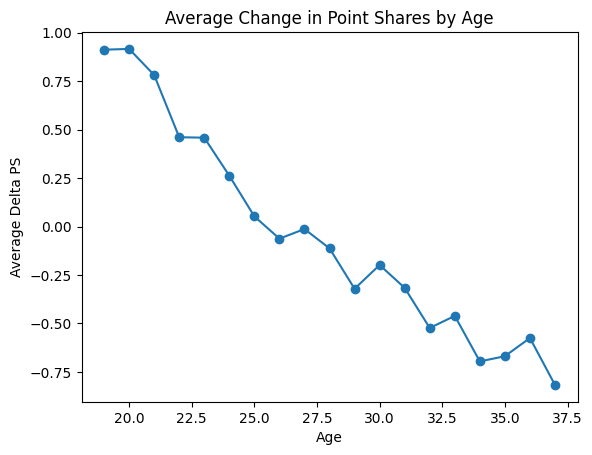

In [9]:
df_filtered = df[df["age"] <= 37]
age_avg = df_filtered.groupby("age")["delta_ps"].mean()

plt.plot(age_avg.index, age_avg.values, marker="o")
plt.xlabel("Age")
plt.ylabel("Average Delta PS")
plt.title("Average Change in Point Shares by Age")
plt.show()


#we put an upper bound of 37 on the graph because that is when the data starts fluctuating too heavily due to a small n

Progression turns to regression over time. This makes sense. Interestingly, this graph indicates that players peak in productivity around age 25, which is not what I would have expected.

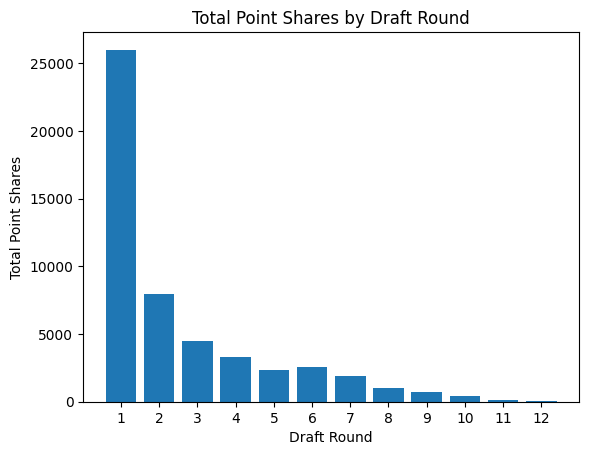

In [10]:
ps_by_round = df.groupby("draft_round")["point_shares"].sum()

plt.bar(ps_by_round.index.astype(str), ps_by_round.values)
plt.xlabel("Draft Round")
plt.ylabel("Total Point Shares")
plt.title("Total Point Shares by Draft Round")
plt.show()

Shows how much more valuable first round picks are than others. Also shows how theres isnt a huge difference in values of picks 4-7. However, with those smaller hit rates there is more susceptibility to the dataset being thrown off by outliers.

There is a drop off after round 7 because the draft is no longer that long i.e. there have been more picks for rounds 1-7 than for rounds 8-12. For round 1-7 because there have been the same total number of picks made for each draft this data also fairly mirrors the average value of picks in each round (but that is for later in my model).

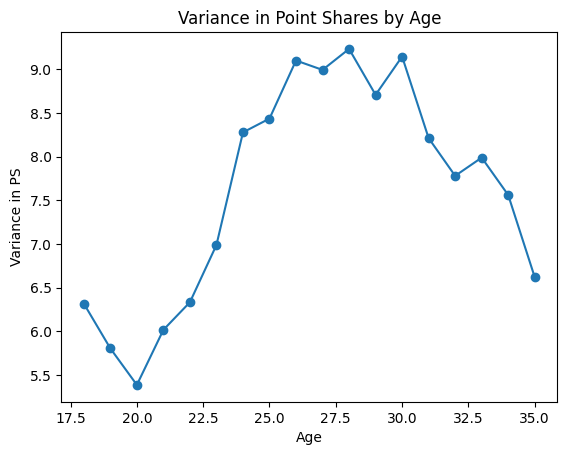

In [11]:
df_filtered = df[df["age"] <= 35]
age_avg = df_filtered.groupby("age")["point_shares"].var()

plt.plot(age_avg.index, age_avg.values, marker="o")
plt.xlabel("Age")
plt.ylabel("Variance in PS")
plt.title("Variance in Point Shares by Age")
plt.show()

This is pretty logical. Players who break into the league young all tend to be at about the same entry level, but players in their mid to late 20s can range from fringe NHLers to Hall of Famers. As players age, they regress back to a lower level with less variance.

Now for the fun one:

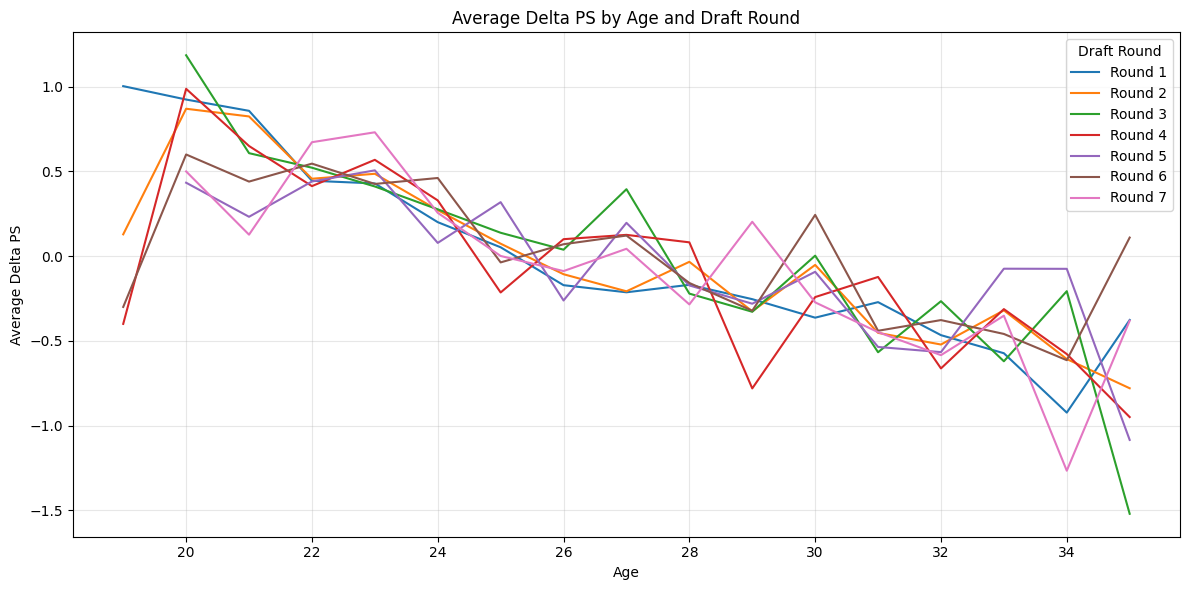

In [12]:
df_filtered = df[df["age"] <= 35]
grouped = df_filtered.groupby(['age', 'draft_round'])['delta_ps'].mean().reset_index()

plt.figure(figsize=(12, 6))

for round_num in range(1, 8):
    round_data = grouped[grouped['draft_round'] == round_num].sort_values('age')
    plt.plot(round_data['age'], round_data['delta_ps'], marker='None', label=f'Round {round_num}')

plt.xlabel('Age')
plt.ylabel('Average Delta PS')
plt.title('Average Delta PS by Age and Draft Round')
plt.legend(title='Draft Round')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

This is really cool and helps us determine something important about our regression model: draft_round should have a very light impact on our prediction, as there doesn't seem to be any meaningful differences. For example, do we really want all 6th round players to be given a sifgnificant boost to valuation ahead of their age 30 season? Or 4th rounders a big cut ahead of age 29? Realistically, draft round has minimal impact by this point. The fact that Andrew Mangiapane was a 6th rounder doesn't really play a factor when we are figuring out what to expect from him next year.

***Modeling Time***

First, lets check which variances are strongest and should be weighted most heavily in our prediction model

In [13]:
variables = [
    'draft_round', 'age', 'games_played', 'cumulative_gp',
    'seasons_played', 'point_shares', 'point_shares_prev1',
    'point_shares_prev2', 'point_shares_prev3', 'delta_ps'
]

correlations = df[variables + ['next_season_ps']].corr()['next_season_ps'].drop('next_season_ps').sort_values(key=abs, ascending=False)
print(correlations)

point_shares          0.696949
point_shares_prev1    0.611635
point_shares_prev2    0.543315
point_shares_prev3    0.489942
games_played          0.432437
cumulative_gp         0.288636
seasons_played        0.197340
draft_round          -0.188608
delta_ps              0.101157
age                   0.072025
Name: next_season_ps, dtype: float64


Some cool data! It follows that the most heavily correlated data is point shares over the current year, with each of the past years getting less and less relevant.

However, we still have a couple concerns:
* Age and draft_round work together in a way that we want to account for
* Age has a relatively parabolic reaction with player production. As seen above, delta_ps by age (first order derivative of ps by age) is a linear relationship, implying an inverted parabola for the point_share vs age relationship
* cumulative_gp, seasons_played, and age will all tend to move together, but are important factors to consider when weighing up development. We may want to introduce a colinearity factor here! Experience is important to consider in development, but can also just reflect age

Lets address these problems now.

In [14]:
concern_vars = ['age', 'draft_round', 'cumulative_gp', 'seasons_played']
collinearity_check = df[concern_vars].corr()
print(collinearity_check)

                     age  draft_round  cumulative_gp  seasons_played
age             1.000000     0.128073       0.831486        0.887285
draft_round     0.128073     1.000000      -0.164980       -0.137874
cumulative_gp   0.831486    -0.164980       1.000000        0.957173
seasons_played  0.887285    -0.137874       0.957173        1.000000


So what we see is that seasons_played and cumulative_gp are very closely correlated. I think that it makes sense to drop seasons_played and just keep cumulative_gp, as it reflects career experience in a more accurate way.
Age and cumulative_gp are closely correlated as well, but both are important factors to consider when evaluating a player's development. The way we are gonna want to handle this is by creating a variable for residual games played by age. This way we can account for more experienced players (especially young players). Take as an example:
* Player A: 23 years old, rookie, 0 Games Played
* Player B: 23 years old, 4 years of NHL experience, 250 Games Played

These players have very different situations and we should treat them as such

In [19]:
df = df.dropna(subset=['age'])

slope, intercept, r, p, se = stats.linregress(df['age'], df['cumulative_gp'])
df['cumulative_gp_residual'] = df['cumulative_gp'] - (slope * df['age'] + intercept)

print(df[['age', 'cumulative_gp_residual']].corr())

                                 age  cumulative_gp_residual
age                     1.000000e+00            5.189479e-15
cumulative_gp_residual  5.189479e-15            1.000000e+00


Cool, we can see that there is no correlation between the variables here, and has allowed us to not double count the experience. Players experience will be accounted for in their age, as well as their residual games played (experience less expected)

Now we have to deal with the fact that age will probably have a parabolic effect on player point shares, lets create that variable.

In [23]:
df['age_squared'] = df['age'] ** 2

print(df[['age', 'age_squared']].head(15))

     age  age_squared
0   18.0        324.0
1   19.0        361.0
2   20.0        400.0
3   21.0        441.0
4   22.0        484.0
5   23.0        529.0
6   24.0        576.0
7   25.0        625.0
8   26.0        676.0
9   27.0        729.0
10  28.0        784.0
11  29.0        841.0
12  30.0        900.0
13  31.0        961.0
14  34.0       1156.0


Also lets get that draft round and age covariable going on for players age 20-25 (young enough for prospect status to have an impact, old enough to have sufficient data to use as a predictor)

In [26]:
df['draft_round_age_interaction'] = df.apply(
    lambda row: row['draft_round'] * row['age'] if 20 <= row['age'] <= 25 else 0, axis=1
)

print(df[['age', 'draft_round', 'draft_round_age_interaction']].head(20))

     age  draft_round  draft_round_age_interaction
0   18.0            1                          0.0
1   19.0            1                          0.0
2   20.0            1                         20.0
3   21.0            1                         21.0
4   22.0            1                         22.0
5   23.0            1                         23.0
6   24.0            1                         24.0
7   25.0            1                         25.0
8   26.0            1                          0.0
9   27.0            1                          0.0
10  28.0            1                          0.0
11  29.0            1                          0.0
12  30.0            1                          0.0
13  31.0            1                          0.0
14  34.0            1                          0.0
15  35.0            1                          0.0
16  36.0            1                          0.0
17  37.0            1                          0.0
18  19.0            1          

This is cool but doesn't really apply to how I want this to actually work. I want the age to be more or less a binary variable that enables draft round as a variable when need be.
We are gonna create this variable with a convex impact as 

In [32]:
df['draft_round_weighted'] = df.apply(
    lambda row: row['draft_round'] if 20 <= row['age'] <= 25 else 0, axis=1
)

Okay lets get a better understanding of these new variables, and check to make sure that there aren't any missing data points that will break the regression.

In [33]:
df.isna().sum()

player_name                        0
player_id                          0
position                           0
draft_year                         0
draft_round                        0
draft_pick                     20967
draft_team                         0
season                             0
age                                0
team                               0
league                             0
games_played                       0
cumulative_gp                      0
seasons_played                     0
point_shares                       0
point_shares_prev1              3257
point_shares_prev2              6007
point_shares_prev3              8399
delta_ps                        3257
next_season_ps                  3257
cumulative_gp_residual             0
age_squared                        0
draft_round_age_interaction        0
draft_round_weighted               0
dtype: int64

Draft pick doesnt matter. The other ones can just be set to 0 as they represent players not playing in those seasons.

In [36]:
df = df[df['season'] != '2025-26']

fill_cols = ['point_shares_prev1', 'point_shares_prev2', 'point_shares_prev3', 'delta_ps', 'next_season_ps']
df[fill_cols] = df[fill_cols].fillna(0)

print(df[fill_cols + ['next_season_ps']].isnull().sum())
print(f"\nRows remaining: {len(df)}")

point_shares_prev1    0
point_shares_prev2    0
point_shares_prev3    0
delta_ps              0
next_season_ps        0
next_season_ps        0
dtype: int64

Rows remaining: 20165


In [37]:
features = [
    'point_shares', 'point_shares_prev1', 'point_shares_prev2', 'point_shares_prev3',
    'games_played', 'age', 'age_squared', 'cumulative_gp_residual',
    'draft_round_weighted', 'delta_ps'
]

correlations = df[features + ['next_season_ps']].corr()['next_season_ps'].drop('next_season_ps').sort_values(key=abs, ascending=False)
print(correlations)

point_shares              0.716662
point_shares_prev1        0.609387
point_shares_prev2        0.516251
games_played              0.470921
cumulative_gp_residual    0.439097
point_shares_prev3        0.438977
draft_round_weighted     -0.152067
delta_ps                  0.116841
age                       0.009009
age_squared               0.003709
Name: next_season_ps, dtype: float64


We're making some good progress

From looking into it, it would be overly complicated to use feature engineering to do the draft pick variable how i want. We'll do it later

In [41]:
!pip install scikit-learn

  Obtaining dependency information for scikit-learn from https://files.pythonhosted.org/packages/58/37/31b83b2594105f61a381fc74ca19e8780ee923be2d496fcd8d2e1147bd99/scikit_learn-1.8.0-cp313-cp313-macosx_12_0_arm64.whl.metadata
  Obtaining dependency information for joblib>=1.3.0 from https://files.pythonhosted.org/packages/7b/91/984aca2ec129e2757d1e4e3c81c3fcda9d0f85b74670a094cc443d9ee949/joblib-1.5.3-py3-none-any.whl.metadata
  Obtaining dependency information for threadpoolctl>=3.2.0 from https://files.pythonhosted.org/packages/32/d5/f9a850d79b0851d1d4ef6456097579a9005b31fea68726a4ae5f2d82ddd9/threadpoolctl-3.6.0-py3-none-any.whl.metadata
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.0/8.0 MB 20.2 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 309.1/309.1 kB 15.6 MB/s eta 0:00:00

[notice] A new release of pip is available: 23.2.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [43]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error

# Create interaction term
df['age_draft_interaction'] = df['age'] * df['draft_round_weighted']

# Define features
features = [
    'point_shares', 'point_shares_prev1', 'point_shares_prev2', 'point_shares_prev3',
    'games_played', 'cumulative_gp_residual', 'draft_round_weighted',
    'delta_ps', 'age', 'age_squared', 'age_draft_interaction'
]

X = df[features]
y = df['next_season_ps']

# Split into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Fit model
model = LinearRegression()
model.fit(X_train, y_train)

# Evaluate
y_pred = model.predict(X_test)
print(f"R² Score: {r2_score(y_test, y_pred):.4f}")
print(f"RMSE: {mean_squared_error(y_test, y_pred)**0.5:.4f}")

# Coefficients
coef_df = pd.DataFrame({'feature': features, 'coefficient': model.coef_}).sort_values('coefficient', ascending=False)
print(coef_df)

R² Score: 0.5644
RMSE: 1.8370
                   feature  coefficient
0             point_shares     0.730380
2       point_shares_prev2     0.100970
3       point_shares_prev3     0.073163
10   age_draft_interaction     0.011428
4             games_played     0.004351
9              age_squared     0.001433
5   cumulative_gp_residual     0.000115
1       point_shares_prev1    -0.040314
8                      age    -0.226174
7                 delta_ps    -0.258974
6     draft_round_weighted    -0.300832


Solid regression but I think we can make it a bit better. Lets check for any potential issues in the regression model

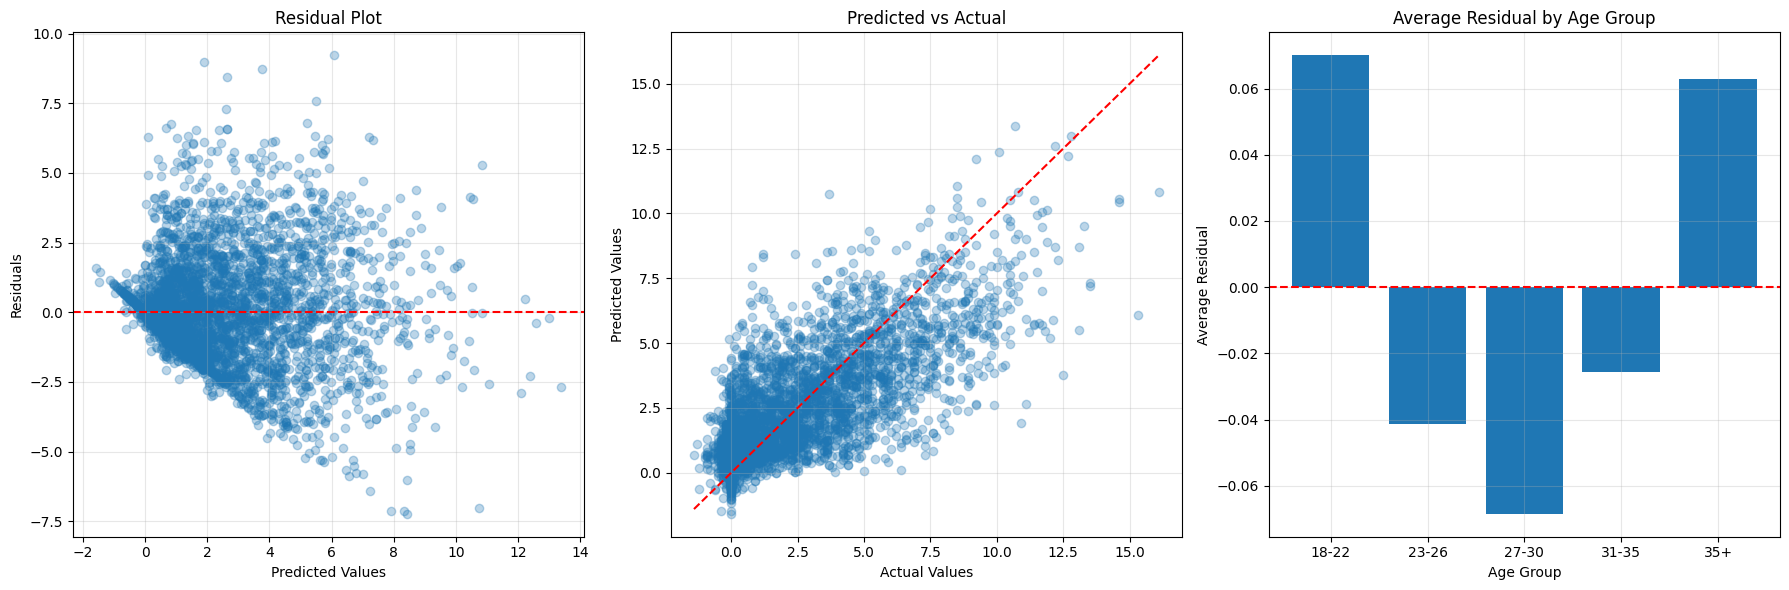

In [44]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# 1. Residual plot
residuals = y_test - y_pred
axes[0].scatter(y_pred, residuals, alpha=0.3)
axes[0].axhline(y=0, color='red', linestyle='--')
axes[0].set_xlabel('Predicted Values')
axes[0].set_ylabel('Residuals')
axes[0].set_title('Residual Plot')
axes[0].grid(True, alpha=0.3)

# 2. Predicted vs Actual
axes[1].scatter(y_test, y_pred, alpha=0.3)
axes[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
axes[1].set_xlabel('Actual Values')
axes[1].set_ylabel('Predicted Values')
axes[1].set_title('Predicted vs Actual')
axes[1].grid(True, alpha=0.3)

# 3. Residuals by age group
X_test_copy = X_test.copy()
X_test_copy['residual'] = residuals
X_test_copy['age_group'] = pd.cut(X_test_copy['age'], bins=[18, 22, 26, 30, 35, 45], labels=['18-22', '23-26', '27-30', '31-35', '35+'])
age_group_residuals = X_test_copy.groupby('age_group')['residual'].mean()
axes[2].bar(age_group_residuals.index, age_group_residuals.values)
axes[2].axhline(y=0, color='red', linestyle='--')
axes[2].set_xlabel('Age Group')
axes[2].set_ylabel('Average Residual')
axes[2].set_title('Average Residual by Age Group')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

The first two graphs look great, but the the third represents a serious problem in our model. We are slightly overrating young and very old players and slightly underrating players age 23-35.

However, this may not be the end of the world. Very few NHL players over the age of 35 stick around for long, so I don't think that will really be too much of a drawback for our player valuation model long term. Additionally, it makes sense that it is more likely for young players to exceed expectations and for mid career players to have unexpected drop offs in production.

You may also notice a strong line in the residual plot angles down about 45 degrees. This is for players with 0 point shares. Many players with very low expectations just end up never playing in the league again, whether that be from failing out or retiring.

In [45]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(model, X, y, cv=5, scoring='r2')

print(f"CV R² Scores: {cv_scores}")
print(f"Mean R²: {cv_scores.mean():.4f}")
print(f"Std Dev: {cv_scores.std():.4f}")

CV R² Scores: [0.54197982 0.55858851 0.58346341 0.54307758 0.61780349]
Mean R²: 0.5690
Std Dev: 0.0286


Using AI tools to revise our model further...

In [46]:
from sklearn.linear_model import RidgeCV, LassoCV
from sklearn.preprocessing import StandardScaler

# Scale features first (required for Ridge/Lasso)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Ridge - finds best alpha automatically
ridge = RidgeCV(alphas=[0.001, 0.01, 0.1, 1, 10, 100], cv=5)
ridge.fit(X_scaled, y)
print(f"Best Ridge alpha: {ridge.alpha_}")
print(f"Ridge R²: {ridge.best_score_:.4f}")

# Lasso - finds best alpha automatically
lasso = LassoCV(cv=5)
lasso.fit(X_scaled, y)
print(f"Best Lasso alpha: {lasso.alpha_:.4f}")
print(f"Lasso R²: {lasso.score(X_scaled, y):.4f}")

Best Ridge alpha: 10.0
Ridge R²: 0.5690
Best Lasso alpha: 0.0021
Lasso R²: 0.5728


In [47]:
lasso_coef = pd.DataFrame({
    'feature': features,
    'coefficient': lasso.coef_
}).sort_values('coefficient', ascending=False)

print(lasso_coef)
print(f"\nVariables dropped by Lasso: {lasso_coef[lasso_coef['coefficient'] == 0]['feature'].tolist()}")

                   feature  coefficient
0             point_shares     1.990556
2       point_shares_prev2     0.268315
3       point_shares_prev3     0.179367
4             games_played     0.120271
5   cumulative_gp_residual     0.032489
9              age_squared     0.000000
10   age_draft_interaction    -0.000000
1       point_shares_prev1    -0.037843
6     draft_round_weighted    -0.063832
7                 delta_ps    -0.496061
8                      age    -0.604272

Variables dropped by Lasso: ['age_squared', 'age_draft_interaction']


In [48]:
features_clean = [
    'point_shares', 'point_shares_prev1', 'point_shares_prev2', 'point_shares_prev3',
    'games_played', 'cumulative_gp_residual', 'draft_round_weighted',
    'delta_ps', 'age'
]

X_clean = df[features_clean]
y = df['next_season_ps']

X_train, X_test, y_train, y_test = train_test_split(X_clean, y, test_size=0.2, random_state=42)

model_clean = LinearRegression()
model_clean.fit(X_train, y_train)

y_pred_clean = model_clean.predict(X_test)
print(f"R²: {r2_score(y_test, y_pred_clean):.4f}")
print(f"RMSE: {mean_squared_error(y_test, y_pred_clean)**0.5:.4f}")

coef_df = pd.DataFrame({'feature': features_clean, 'coefficient': model_clean.coef_}).sort_values('coefficient', ascending=False)
print(coef_df)

R²: 0.5641
RMSE: 1.8378
                  feature  coefficient
0            point_shares     0.736738
2      point_shares_prev2     0.100011
3      point_shares_prev3     0.070638
4            games_played     0.004323
5  cumulative_gp_residual     0.000164
6    draft_round_weighted    -0.032211
1      point_shares_prev1    -0.045925
8                     age    -0.143416
7                delta_ps    -0.264993


In [49]:
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(y_test, y_pred_clean)
print(f"Mean Absolute Error: {mae:.4f}")

Mean Absolute Error: 1.3455


This isn't perfect, but realistically pretty good for what we are working with. The R^2 is fine for a model like this, as it represents a decent prediction, but doesn't reflect data leakage or overfitting. Lets try and include position as a piece of this model, because defensemen progress differently than forwards.

In [52]:
print(df['position'].value_counts())

position
D        6895
C        5720
RW       3591
LW       3513
C/LW      214
C/RW      109
W          34
C/W        30
LW/C       16
RW/C       11
C; LW      11
L/RW        9
C RW        8
D/W         2
C/D         1
F           1
Name: count, dtype: int64


In [53]:
def map_position(pos):
    if pd.isna(pos):
        return None
    pos = str(pos).upper()
    if 'D' in pos and 'W' not in pos:
        return 'D'
    else:
        return 'F'

df['position_group'] = df['position'].apply(map_position)
print(df['position_group'].value_counts())
print(f"Nulls: {df['position_group'].isna().sum()}")

position_group
F    13269
D     6896
Name: count, dtype: int64
Nulls: 0


In [54]:
results = {}

for pos in ['F', 'D']:
    pos_df = df[df['position_group'] == pos]
    
    X_pos = pos_df[features_clean]
    y_pos = pos_df['next_season_ps']
    
    X_train, X_test, y_train, y_test = train_test_split(X_pos, y_pos, test_size=0.2, random_state=42)
    
    pos_model = LinearRegression()
    pos_model.fit(X_train, y_train)
    
    y_pred = pos_model.predict(X_test)
    
    r2 = r2_score(y_test, y_pred)
    rmse = mean_squared_error(y_test, y_pred)**0.5
    mae = mean_absolute_error(y_test, y_pred)
    
    results[pos] = {'model': pos_model, 'r2': r2, 'rmse': rmse, 'mae': mae}
    
    print(f"\n{pos} Model:")
    print(f"R²: {r2:.4f} | RMSE: {rmse:.4f} | MAE: {mae:.4f}")
    
    coef_df = pd.DataFrame({'feature': features_clean, 'coefficient': pos_model.coef_}).sort_values('coefficient', ascending=False)
    print(coef_df)


F Model:
R²: 0.5594 | RMSE: 1.8920 | MAE: 1.3613
                  feature  coefficient
0            point_shares     0.776853
2      point_shares_prev2     0.120413
3      point_shares_prev3     0.056173
4            games_played     0.003300
5  cumulative_gp_residual     0.000372
6    draft_round_weighted    -0.035700
1      point_shares_prev1    -0.082993
8                     age    -0.138266
7                delta_ps    -0.302838

D Model:
R²: 0.5198 | RMSE: 1.8941 | MAE: 1.4229
                  feature  coefficient
0            point_shares     0.658313
2      point_shares_prev2     0.088030
3      point_shares_prev3     0.075706
4            games_played     0.006228
5  cumulative_gp_residual     0.000221
1      point_shares_prev1    -0.000024
6    draft_round_weighted    -0.019188
8                     age    -0.149447
7                delta_ps    -0.209990


Okay so the takeaway from this is that the model is weaker when divided into the two groups as the data set will be smaller for each regression created. As a result, we're honestly just gonna leave it with the one regression

In [55]:
features_clean = [
    'point_shares', 'point_shares_prev1', 'point_shares_prev2', 'point_shares_prev3',
    'games_played', 'cumulative_gp_residual', 'draft_round_weighted',
    'delta_ps', 'age'
]

X = df[features_clean]
y = df['next_season_ps']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

final_model = LinearRegression()
final_model.fit(X_train, y_train)

y_pred = final_model.predict(X_test)
print(f"R²: {r2_score(y_test, y_pred):.4f}")
print(f"RMSE: {mean_squared_error(y_test, y_pred)**0.5:.4f}")
print(f"MAE: {mean_absolute_error(y_test, y_pred):.4f}")

R²: 0.5641
RMSE: 1.8378
MAE: 1.3455


In [56]:
print(f"next_season_ps = ")
for feature, coef in zip(features_clean, final_model.coef_):
    print(f"  + ({coef:.6f} * {feature})")
print(f"  + {final_model.intercept_:.6f}")

next_season_ps = 
  + (0.736738 * point_shares)
  + (-0.045925 * point_shares_prev1)
  + (0.100011 * point_shares_prev2)
  + (0.070638 * point_shares_prev3)
  + (0.004323 * games_played)
  + (0.000164 * cumulative_gp_residual)
  + (-0.032211 * draft_round_weighted)
  + (-0.264993 * delta_ps)
  + (-0.143416 * age)
  + 3.930162


Okay I am not gonna get into all the details of what every coefficieny here is but a couple important ones would be that the negative coefficient for delta_ps represent regression to the mean, and everything else mostly checks out.

Lets check out what a couple players point shares were expected to be for last year.

In [57]:
players = ['Matthew Knies', 'Connor Bedard', 'Connor McDavid', 'Connor Dewar']

latest = df[df['player_name'].isin(players)].sort_values('season').groupby('player_name').last().reset_index()
player_features = latest[features_clean]

predictions = final_model.predict(player_features)

results = pd.DataFrame({
    'player': latest['player_name'],
    'season': latest['season'],
    'actual_ps': latest['point_shares'],
    'predicted_next_season_ps': predictions.round(2)
})

print(results)

           player   season  actual_ps  predicted_next_season_ps
0   Connor Bedard  2024-25        5.3                      5.15
1    Connor Dewar  2024-25        0.7                      0.88
2  Connor McDavid  2024-25       10.7                     11.20
3   Matthew Knies  2024-25        6.5                      4.82


In [58]:
from scipy import stats
slope, intercept, r, p, se = stats.linregress(df['age'], df['cumulative_gp'])
print(f"Slope: {slope:.6f}")
print(f"Intercept: {intercept:.6f}")

Slope: 56.895695
Intercept: -1168.569389


Pretty cool! We underrated bedard a little bit, Knies a lot, and overrated the other two by a little bit. But that also probably represents how players did relative to expectations last year!

**Thats all for Day 1**

A couple things I want to accomplish going forward:

Establish a baseline market value system (likely centered around pre existing work connecting cap space and draft capital).
Figure out what the "true" value of players is in terms of cap hit relative to point share.
Use financial asset pricing methods to evaluate a player value as an annuity with increasing risk over time

Ultimately, this will result in being able to calculate a "true" and "market" dollar value for any player/prospect/pick and will allow us to weigh up potential trades and analyze asset management trends in the NHL. Fun!